# 02 - Exploratory Data Analysis
### Google Play Store App Analytics

Comprehensive EDA on the cleaned dataset covering dataset overview, category
performance, ratings, installs, pricing, engagement, and app size.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/processed/googleplaystore_cleaned.csv')
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
df.shape

(9659, 23)

## A. Dataset Overview

In [2]:
overview = {
    'Total apps': len(df),
    'Unique categories': df['category'].nunique(),
    'Free apps': (df['type'] == 'Free').sum(),
    'Paid apps': (df['type'] == 'Paid').sum(),
    'Apps with rating': df['rating'].notna().sum(),
    'Apps without rating': df['rating'].isna().sum(),
    'Unique apps': df['app'].nunique(),
}
for k, v in overview.items():
    print(f'{k}: {v}')

Total apps: 9659
Unique categories: 33
Free apps: 8905
Paid apps: 754
Apps with rating: 8196
Apps without rating: 1463
Unique apps: 9659


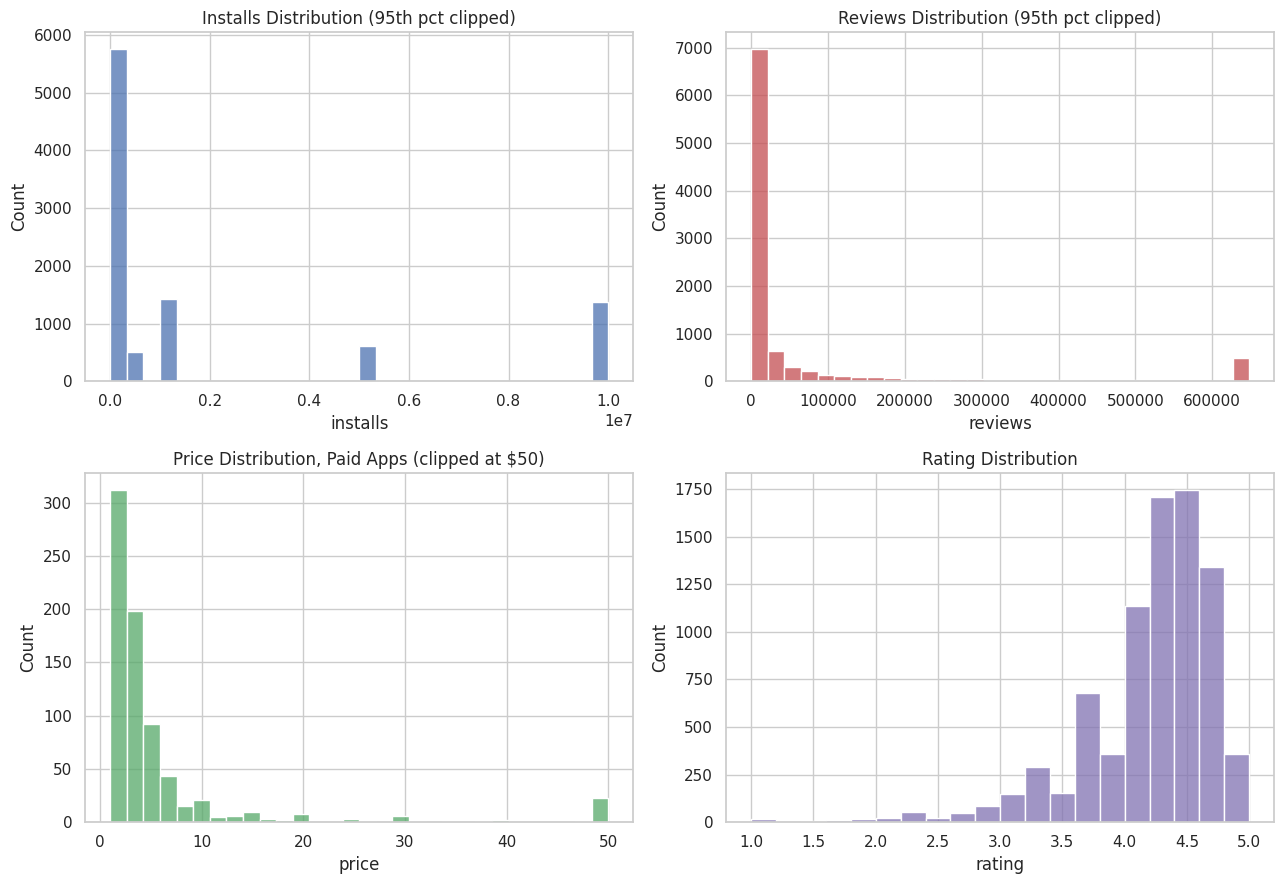

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df['installs'].clip(upper=df['installs'].quantile(0.95)), bins=30, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Installs Distribution (95th pct clipped)')

sns.histplot(df['reviews'].clip(upper=df['reviews'].quantile(0.95)), bins=30, ax=axes[0,1], color='#C44E52')
axes[0,1].set_title('Reviews Distribution (95th pct clipped)')

sns.histplot(df.loc[df['type']=='Paid', 'price'].clip(upper=50), bins=30, ax=axes[1,0], color='#55A868')
axes[1,0].set_title('Price Distribution, Paid Apps (clipped at $50)')

sns.histplot(df['rating'].dropna(), bins=20, ax=axes[1,1], color='#8172B2')
axes[1,1].set_title('Rating Distribution')

plt.tight_layout()
plt.show()

## B. Category Analysis

In [4]:
category_summary = df.groupby('category').agg(
    app_count=('app', 'count'),
    avg_rating=('rating', 'mean'),
    median_rating=('rating', 'median'),
    total_reviews=('reviews', 'sum'),
    avg_reviews=('reviews', 'mean'),
    total_installs=('installs', 'sum'),
    avg_installs=('installs', 'mean'),
).reset_index()

paid_pct = df.groupby('category')['is_free'].apply(lambda x: round((1 - x.mean()) * 100, 2))
category_summary['pct_paid'] = category_summary['category'].map(paid_pct)
category_summary = category_summary.sort_values('total_installs', ascending=False)
category_summary.head(10)

,category,app_count,avg_rating,median_rating,total_reviews,avg_reviews,total_installs,avg_installs,pct_paid
14,GAME,946,4.244605,4.3,590772190,624494.915433,13457924415,1.422614e+07,8.67
6,COMMUNICATION,315,4.121484,4.2,285824082,907378.038095,11038276251,3.504215e+07,8.57
29,TOOLS,829,4.040278,4.2,229471630,276805.343788,8102771915,9.774152e+06,9.41
11,FAMILY,1876,4.183767,4.3,193600852,103198.748401,6226542505,3.319053e+06,9.86
25,PRODUCTIVITY,374,4.183389,4.3,55590856,148638.652406,5793091369,1.548955e+07,7.49
27,SOCIAL,239,4.247291,4.3,227936355,953708.598326,5487867902,2.296179e+07,1.26
24,PHOTOGRAPHY,281,4.155894,4.3,105580472,375731.217082,4658147655,1.657704e+07,6.76
31,VIDEO_PLAYERS,164,4.044966,4.2,67644444,412466.121951,3931902720,2.397502e+07,2.44
30,TRAVEL_AND_LOCAL,219,4.069519,4.2,26821349,122471.913242,2894887146,1.321866e+07,5.48
21,NEWS_AND_MAGAZINES,254,4.121569,4.2,23130682,91065.677165,2369217760,9.327629e+06,0.79


In [5]:
print('Top categories by installs:')
print(category_summary.sort_values('total_installs', ascending=False).head(5)[['category','total_installs']])
print()
print('Top categories by rating:')
print(category_summary.sort_values('avg_rating', ascending=False).head(5)[['category','avg_rating']])
print()
print('Top categories by reviews:')
print(category_summary.sort_values('total_reviews', ascending=False).head(5)[['category','total_reviews']])
print()
print('Most competitive categories (highest app count):')
print(category_summary.sort_values('app_count', ascending=False).head(5)[['category','app_count']])
print()
print('Highest monetisation potential (pct paid, min 20 apps):')
print(category_summary[category_summary['app_count']>=20].sort_values('pct_paid', ascending=False).head(5)[['category','pct_paid']])

Top categories by installs:
         category  total_installs
14           GAME     13457924415
6   COMMUNICATION     11038276251
29          TOOLS      8102771915
11         FAMILY      6226542505
25   PRODUCTIVITY      5793091369

Top categories by rating:
               category  avg_rating
10               EVENTS    4.435556
0        ART_AND_DESIGN    4.359322
8             EDUCATION    4.351429
3   BOOKS_AND_REFERENCE    4.344970
23      PERSONALIZATION    4.332215

Top categories by reviews:
         category  total_reviews
14           GAME      590772190
6   COMMUNICATION      285824082
29          TOOLS      229471630
27         SOCIAL      227936355
11         FAMILY      193600852

Most competitive categories (highest app count):
    category  app_count
11    FAMILY       1876
14      GAME        946
29     TOOLS        829
4   BUSINESS        420
20   MEDICAL        395

Highest monetisation potential (pct paid, min 20 apps):
               category  pct_paid
23      PERSON

## C. Rating Analysis

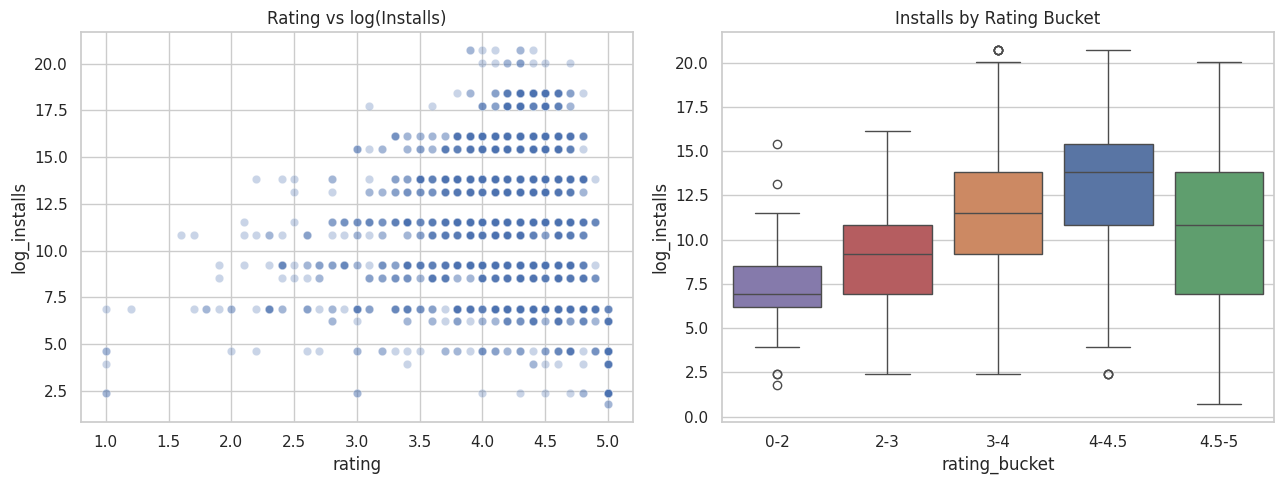

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df.sample(min(3000,len(df)), random_state=42), x='rating', y='log_installs', alpha=0.3, ax=axes[0])
axes[0].set_title('Rating vs log(Installs)')

sns.boxplot(data=df, x='rating_bucket', y='log_installs', hue='rating_bucket', order=['0-2','2-3','3-4','4-4.5','4.5-5'], ax=axes[1], legend=False)
axes[1].set_title('Installs by Rating Bucket')
plt.tight_layout()
plt.show()

In [7]:
rating_installs = df.groupby('rating_bucket', observed=True)['installs'].mean().reindex(['0-2','2-3','3-4','4-4.5','4.5-5'])
print(rating_installs)
print()
print('Do highly rated apps get more installs? The relationship is NOT strictly monotonic:')
print('installs rise sharply up to the 4-4.5 bucket, then apps in the very top 4.5-5 bucket')
print('actually average FEWER installs than the 4-4.5 bucket -- rating alone is a weak install driver.')

rating_bucket
0-2      9.085795e+04
2-3      1.865335e+05
3-4      4.750643e+06
4-4.5    1.378914e+07
4.5-5    5.453027e+06
Name: installs, dtype: float64

Do highly rated apps get more installs? The relationship is NOT strictly monotonic:
installs rise sharply up to the 4-4.5 bucket, then apps in the very top 4.5-5 bucket
actually average FEWER installs than the 4-4.5 bucket -- rating alone is a weak install driver.


## D. Install Analysis

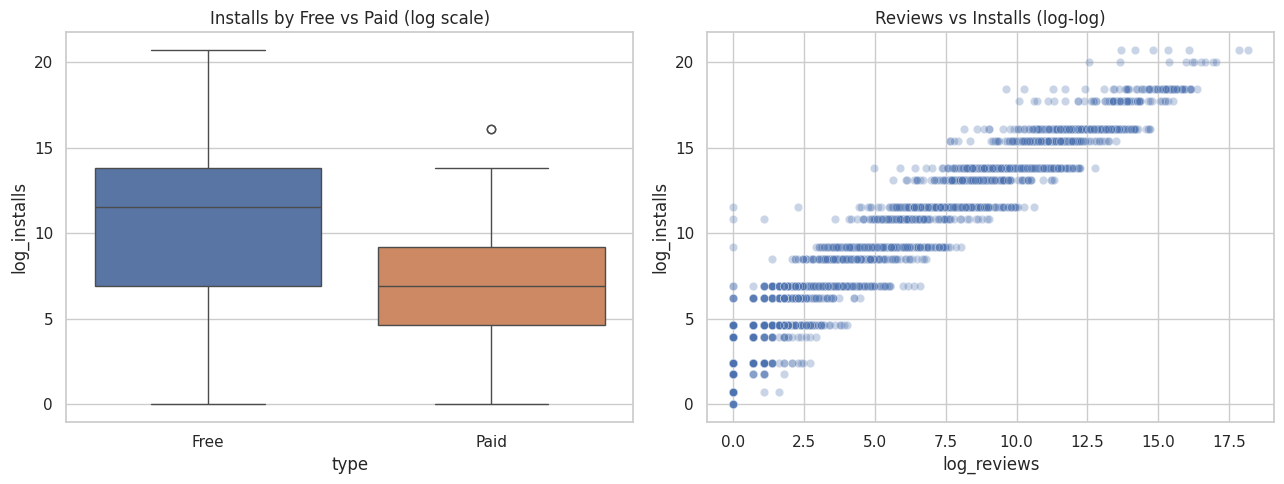

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x='type', y='log_installs', hue='type', ax=axes[0], legend=False)
axes[0].set_title('Installs by Free vs Paid (log scale)')

sns.scatterplot(data=df.sample(min(3000,len(df)), random_state=42), x='log_reviews', y='log_installs', alpha=0.3, ax=axes[1])
axes[1].set_title('Reviews vs Installs (log-log)')
plt.tight_layout()
plt.show()

## E. Pricing Analysis

In [9]:
pricing = df.groupby('price_bucket', observed=True).agg(
    app_count=('app','count'), avg_installs=('installs','mean'), avg_rating=('rating','mean')
).reset_index()
pricing

,price_bucket,app_count,avg_installs,avg_rating
0,$0.01-$1,148,1.310667e+05,4.300943
1,$1-$5,449,4.953371e+04,4.271279
2,$10+,73,1.199777e+04,4.127273
3,$5-$10,84,1.767790e+05,4.258621
4,Free,8905,8.452012e+06,4.166223


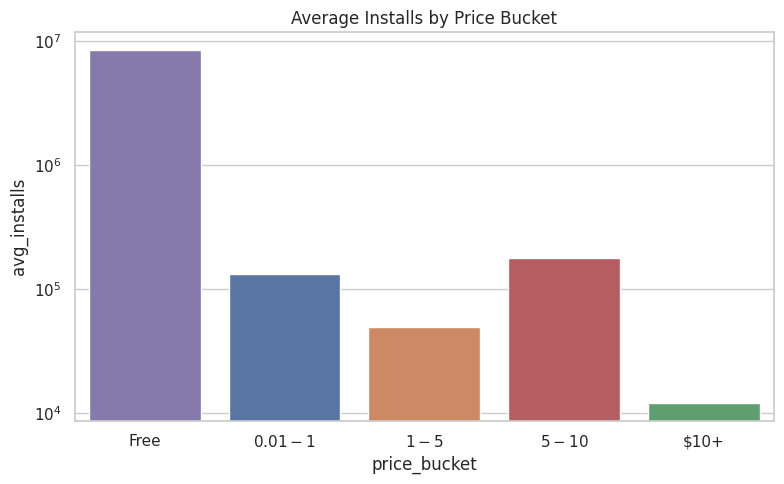

In [10]:
plt.figure(figsize=(8,5))
order = ['Free', '$0.01-$1', '$1-$5', '$5-$10', '$10+']
sns.barplot(data=pricing, x='price_bucket', y='avg_installs', order=order, hue='price_bucket', legend=False)
plt.title('Average Installs by Price Bucket')
plt.yscale('log')
plt.tight_layout()
plt.show()

## F. Reviews and Engagement

In [11]:
print('Review-to-install ratio is a proxy for engagement, NOT a direct measure of')
print('active usage -- it only reflects how many installers left a review.')
print()
engagement = df.dropna(subset=['review_to_install_ratio']).groupby('category')['review_to_install_ratio'].mean().sort_values(ascending=False)
engagement.head(10)

Review-to-install ratio is a proxy for engagement, NOT a direct measure of
active usage -- it only reflects how many installers left a review.



category
GAME                  0.056379
SOCIAL                0.055601
SPORTS                0.048650
MEDICAL               0.045423
PERSONALIZATION       0.042873
AUTO_AND_VEHICLES     0.041873
FAMILY                0.041622
BUSINESS              0.038405
WEATHER               0.037152
HEALTH_AND_FITNESS    0.036738
Name: review_to_install_ratio, dtype: float64

## G. App Size

In [12]:
size_bins = [0,10,30,60,100, df['size_mb'].max()+1]
size_labels = ['<10MB','10-30MB','30-60MB','60-100MB','100MB+']
df['size_bucket_calc'] = pd.cut(df['size_mb'], bins=size_bins, labels=size_labels, include_lowest=True)
size_summary = df.groupby('size_bucket_calc', observed=True).agg(
    app_count=('app','count'), avg_installs=('installs','mean'), avg_rating=('rating','mean')
).reset_index()
size_summary

,size_bucket_calc,app_count,avg_installs,avg_rating
0,<10MB,3930,1.119563e+06,4.131254
1,10-30MB,2600,3.852534e+06,4.175341
2,30-60MB,1301,6.750205e+06,4.164954
3,60-100MB,600,1.377276e+07,4.258979


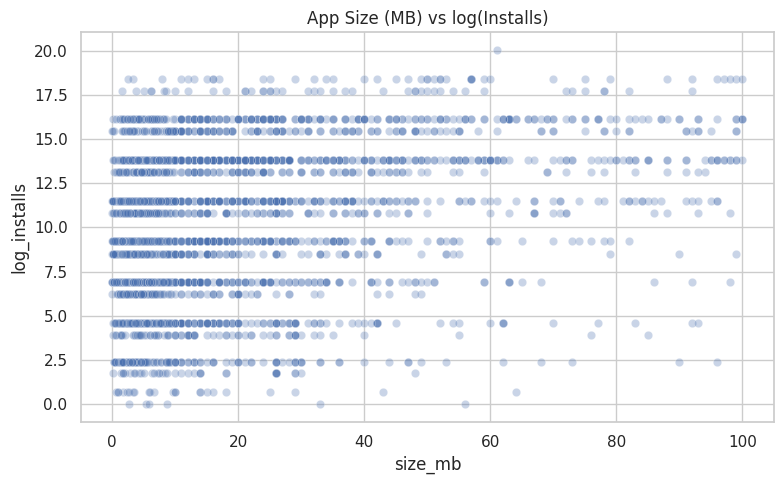

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df.dropna(subset=['size_mb']).sample(min(3000, df['size_mb'].notna().sum()), random_state=42),
                 x='size_mb', y='log_installs', alpha=0.3)
plt.title('App Size (MB) vs log(Installs)')
plt.tight_layout()
plt.show()